# Analisis K-Means Clustering: Efisiensi Bahan Bakar dan Emisi CO2 Kendaraan

## 1. Deskripsi Masalah Utama
Transportasi merupakan salah satu penyumbang terbesar emisi gas rumah kaca global, khususnya karbon dioksida (CO2), yang memicu pemanasan global dan perubahan iklim. Di pasar otomotif saat ini, terdapat ribuan model kendaraan dengan berbagai variasi spesifikasi mesin. Masalah utamanya adalah **sulitnya melakukan segmentasi atau pengelompokan kendaraan secara objektif** untuk mengidentifikasi kategori kendaraan mana yang tergolong ramah lingkungan (efisien) dan mana yang memberikan dampak buruk signifikan terhadap lingkungan (polusi tinggi).

Tanpa adanya pengelompokan yang jelas, pemerintah atau regulator akan kesulitan dalam menentukan kebijakan pajak karbon (*carbon tax*) yang adil, dan produsen otomotif akan sulit memetakan fokus efisiensi teknologi mesin mereka.

## 2. Kenapa Menggunakan Dataset Ini?
Dataset `FuelConsumption.csv` dipilih karena memiliki karakteristik yang sangat ideal untuk menjawab masalah di atas melalui pendekatan *Machine Learning*:

1. **Fitur yang Relevan & Komprehensif:** Dataset ini menyediakan metrik teknis mesin yang krusial seperti kapasitas mesin (`ENGINESIZE`) dan jumlah silinder (`CYLINDERS`), serta dampaknya langsung pada konsumsi bahan bakar (`FUELCONSUMPTION_COMB`) dan emisi gas buang (`CO2EMISSIONS`).
2. **Korelasi Data Numerik yang Kuat:** Hubungan antar fitur dalam dataset ini bersifat linear kontinu (spesifikasi mesin berbanding lurus dengan konsumsi dan emisi). Karakteristik jarak spasial antar data yang jelas ini sangat cocok dieksplorasi menggunakan algoritma *Unsupervised Learning*, khususnya **K-Means Clustering**, untuk menemukan pola pengelompokan alami tanpa perlu label buatan manusia.
3. **Representasi Dunia Nyata:** Data ini mencerminkan variasi kendaraan nyata di pasar, sehingga hasil *clustering* dapat langsung memberikan *insight* yang aplikatif untuk rekomendasi kebijakan lingkungan maupun panduan bagi konsumen.

Sumber dataset: https://www.kaggle.com/datasets/sarita19/fuel-consumption

Anggota Kelompok:
- Alif Zuhair (24523213)
- Qanzul Arays (23523228)
- Muhammad Ibnu Rasyid (23523127)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# 1. Load Dataset
url = 'https://raw.githubusercontent.com/alifzuhair/TUGAS-AKHIR-UNSUPERVISED-FSD/refs/heads/main/FuelConsumption.csv'
df = pd.read_csv(url)
display(df.head())

# 2. Seleksi Fitur Numerik Penting
features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']
X = df[features]

# 3. Standardisasi Fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data berhasil dimuat dan dinormalisasi. Siap untuk proses clustering!")

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


Data berhasil dimuat dan dinormalisasi. Siap untuk proses clustering!


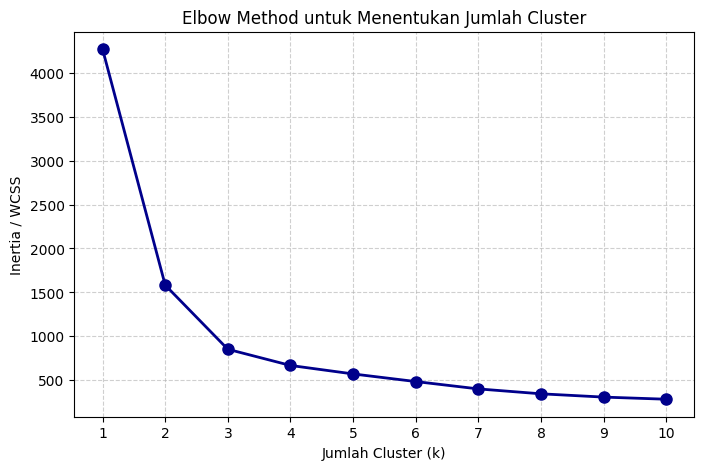

In [ ]:

# Menghitung nilai Inertia (WCSS) untuk jumlah cluster 1 sampai 10
wcss = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# VISUALISASI: Grafik Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K, wcss, 'ro-', color='darkblue', linewidth=2, markersize=8)
plt.title('Elbow Method untuk Menentukan Jumlah Cluster', fontsize=12)
plt.xlabel('Jumlah Cluster (k)', fontsize=10)
plt.ylabel('Inertia / WCSS', fontsize=10)
plt.xticks(K)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Dari Grafik Elbow diatas, dapat dilihat bahwa jumlah cluster (k) yang terbaik adalah k=3, karena penurunan WCSS nya tidak terlalu signifikan/stabil.

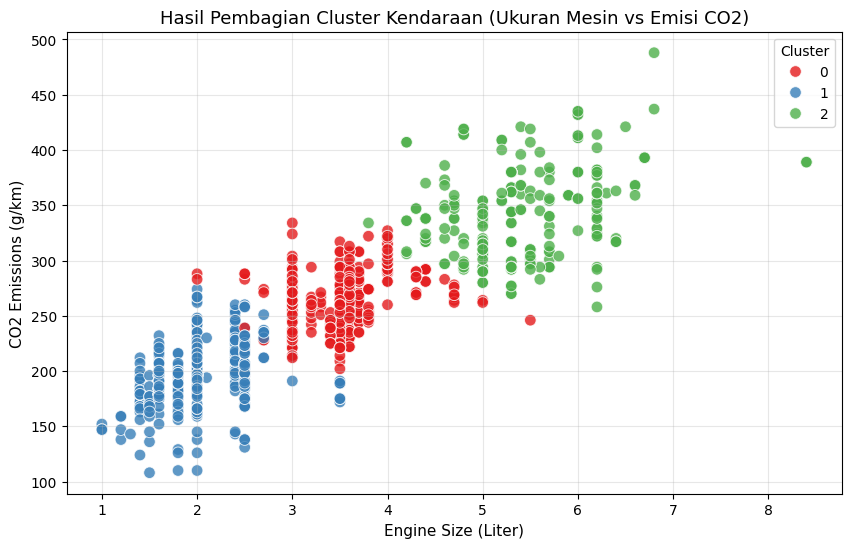

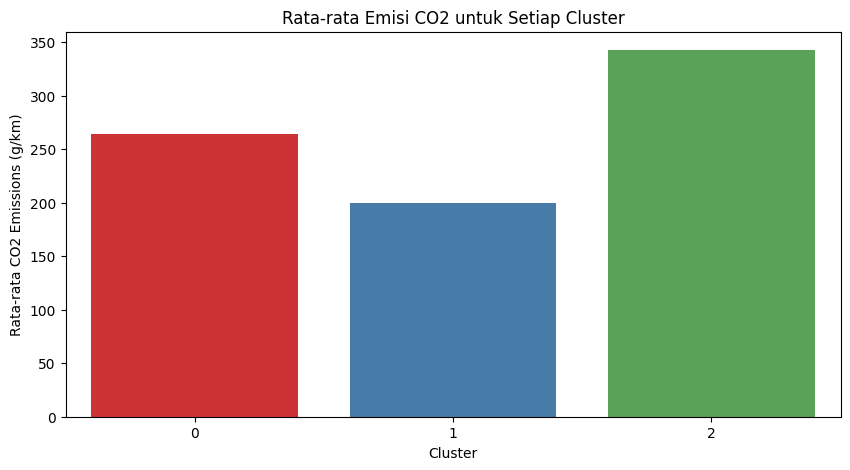

In [ ]:
# 1. Menjalankan K-Means dengan k=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 2. VISUALISASI: Scatter Plot Hasil Clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='ENGINESIZE',
    y='CO2EMISSIONS',
    hue='Cluster',
    palette='Set1',
    s=70,
    alpha=0.8
)
plt.title('Hasil Pembagian Cluster Kendaraan (Ukuran Mesin vs Emisi CO2)', fontsize=13)
plt.xlabel('Engine Size (Liter)', fontsize=11)
plt.ylabel('CO2 Emissions (g/km)', fontsize=11)
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# 3. VISUALISASI: Karakteristik Konsumsi Bahan Bakar vs Emisi per Cluster
plt.figure(figsize=(10, 5))
cluster_summary = df.groupby('Cluster')[features].mean().reset_index()

# Bar Plot Emisi CO2 rata-rata tiap cluster
sns.barplot(data=cluster_summary, x='Cluster', y='CO2EMISSIONS', palette='Set1')
plt.title('Rata-rata Emisi CO2 untuk Setiap Cluster', fontsize=12)
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Rata-rata CO2 Emissions (g/km)', fontsize=10)
plt.show()

### Insight dari hasil clustering

- Temuan Utama: Ada korelasi linier yang sangat kuat antara ukuran mesin dengan emisi gas buang. Grafik scatter plot membuktikan bahwa tidak ada mobil dengan kapasitas mesin besar yang masuk ke kelompok ramah lingkungan (Cluster 0).

- Pola Menarik: Data kendaraan secara alami langsung mengelompok menjadi tiga strata pasar (mobil kecil/kota, mobil keluarga menengah, dan mobil sport/truk besar).

### Kesimpulan dari hasil clustering

- Cluster 0 (Warna Merah) ➔ "Kendaraan Kelas Menengah (Standard / Family Cars)"

Berada di area tengah. Ukuran mesinnya berkapasitas sedang (antara $2.5$ hingga $4.0$ Liter) dengan emisi CO2 yang juga berada di tingkat moderat (berkisar antara $200$ hingga $350\text{ g/km}$).

- Cluster 1 (Warna Biru) ➔ "Kendaraan Ekonomis / Ramah Lingkungan (Eco-Friendly)"

Berada di area kiri bawah. Ini adalah kelompok mobil dengan ukuran mesin paling kecil (berkisar antara $1.0$ hingga $2.5$ Liter) dan menghasilkan emisi CO2 terendah (mayoritas di bawah $250\text{ g/km}$).

- Cluster 2 (Warna Hijau) ➔ "Kendaraan Performa Tinggi / Berbobot Berat (High Performance / Heavy Duty)"

Berada di area kanan atas. Kelompok ini mencakup mobil dengan kapasitas mesin besar (mulai dari $4.0$ hingga di atas $6.0$ Liter, bahkan ada outlier di $8.4$ Liter) dan menghasilkan emisi gas buang CO2 yang sangat tinggi (sebagian besar di atas $300\text{ g/km}$ hingga menyentuh $500\text{ g/km}$).
